In [1]:
!python ~/STEER/diffusers/exchange_scripts/generate_samples.py \
    --lam-start 0.85 --lam-end 1.15 --n-particles 4 \
    --tsr-path "images/tsr_tester" \
    --steer-path "images/steer_tester"

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|████████████| 9/9 [00:19<00:00,  2.18s/it]
Loaded 5 prompts
i=0 pair=(0,1) lam_t=0.85010 lam_s=0.95020 tsr_diff=0.000000 integral_mean=0.000000 integral_std=0.000000 log_ratio=0.0000 accept=1.0000 swapped=True
i=0 pair=(2,3) lam_t=1.05078 lam_s=1.15039 tsr_diff=0.000000 integral_mean=0.000000 integral_std=0.000000 log_ratio=0.0000 accept=1.0000 swapped=True
i=1 pair=(0,3) lam_t=0.95020 lam_s=1.05078 tsr_diff=0.001953 integral_mean=-0.000000 integral_std=0.000028 log_ratio=-0.0374 accept=0.9634 swapped=True
i=2 pair=(1,3) lam_t=0.85010 lam_s=0.95020 tsr_diff=0.002930 integral_mean=-0.000009 integral_std=0.000044 log_ratio=-2.3887 accept=0.0917 swapped=Fal

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.conda/envs/diffusers/lib/python3.10/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 3/3 [00:10<00:00,  3.59s/it]


Real features computed from 265 images.



...

[False]  lam=0.950  FID=138.8214  CLIP=32.5152


CLIP lam=1.05: 100%|██████████| 265/265 [00:11<00:00, 22.26it/s]


[False]  lam=1.050  FID=137.3170  CLIP=32.6587


CLIP lam=1.15: 100%|██████████| 265/265 [00:12<00:00, 20.73it/s]


[False]  lam=1.150  FID=137.8024  CLIP=32.7010


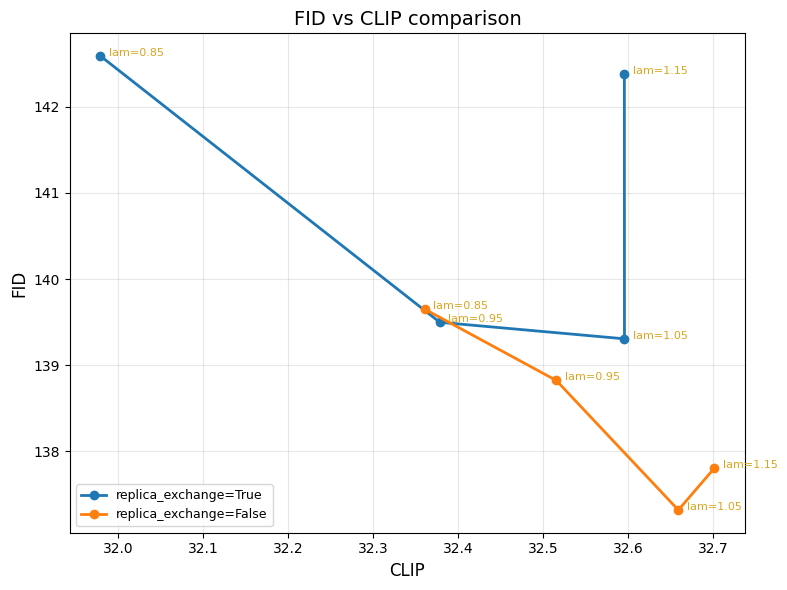

In [2]:
import sys
sys.path.append('~/STEER')  # or use os.path.expanduser('~/STEER')

import importlib.util
import os

path = os.path.expanduser('~/STEER/diffusers/exchange_scripts/fid.py')
spec = importlib.util.spec_from_file_location("generate_samples", path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

compute_sweep = module.compute_sweep

import os 
from pathlib import Path

tsr_results = compute_sweep(
    replica_exchanges=[True, False],
    device="cuda",
    target_indices=None,
    index_until=265,
    tsr_dir=Path("images/tsr"),
    pt_tsr_dir=Path("images/steer_6"),        # fix kwarg name
    lam_values_ptsr=[0.85, 0.95, 1.05, 1.15],
    lam_values_tsr=[0.85, 0.95, 1.05, 1.15],
)